<a href="https://colab.research.google.com/github/glender222/ACP-COMBUSTIBLE/blob/main/proyectoCombustibleipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
ruta = "/content/datacombustible_lpc5deqndn.xlsx"
df = pd.read_excel(ruta)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (19709, 11)


,fecha_emision,fecha_corte,id,producto,fe_inventario,cantidad_mb,fe_proceso,cantidad_mb_lim,vlmen_fndo_ttal,ANON_CO_OSINERG,ANON_PTA_ABASTECIMIENTO
0,20250701,20250701,1,G Premium,2025-01-12 00:00:00,35.98500,2025-01-19 12:10:02,35.98500,0.03300,3dcd3239e2,83ae64708f
1,20250701,20250701,2,G Premium,2025-01-09 00:00:00,0.00000,2025-01-16 12:10:02,0.00000,0.00000,2127ae39c1,fdb7133ee2
2,20250701,20250701,3,G Premium,2025-01-22 00:00:00,0.32607,2025-01-29 12:10:02,0.32607,0.00029,6ef1e6909e,9fc7ed4647
3,20250701,20250701,4,G Premium,2025-02-02 00:00:00,16.21480,2025-02-09 12:10:02,16.21480,2.61570,98feeeb363,335ac645f3
4,20250701,20250701,5,G Premium,2025-01-05 00:00:00,0.00000,2025-01-12 12:10:01,0.00000,0.00000,13c3a19c48,0af6a53b9b


In [3]:
print(df.columns.tolist())
print("\nTipos de dato:")
print(df.dtypes)

print("\nNulos por columna:")
print(df.isna().sum())

['fecha_emision', 'fecha_corte', 'id', 'producto', 'fe_inventario', 'cantidad_mb', 'fe_proceso', 'cantidad_mb_lim', 'vlmen_fndo_ttal', 'ANON_CO_OSINERG', 'ANON_PTA_ABASTECIMIENTO']

Tipos de dato:
fecha_emision                int64
fecha_corte                  int64
id                           int64
producto                    object
fe_inventario               object
cantidad_mb                float64
fe_proceso                  object
cantidad_mb_lim            float64
vlmen_fndo_ttal            float64
ANON_CO_OSINERG             object
ANON_PTA_ABASTECIMIENTO     object
dtype: object

Nulos por columna:
fecha_emision              0
fecha_corte                0
id                         0
producto                   0
fe_inventario              0
cantidad_mb                0
fe_proceso                 0
cantidad_mb_lim            0
vlmen_fndo_ttal            0
ANON_CO_OSINERG            0
ANON_PTA_ABASTECIMIENTO    0
dtype: int64


In [5]:
df["fecha_emision"] = pd.to_datetime(df["fecha_emision"].astype(str), format="%Y%m%d", errors="coerce")
df["fecha_corte"] = pd.to_datetime(df["fecha_corte"].astype(str), format="%Y%m%d", errors="coerce")
df["fe_inventario"] = pd.to_datetime(df["fe_inventario"], errors="coerce")
df["fe_proceso"] = pd.to_datetime(df["fe_proceso"], errors="coerce")

In [6]:
df["dias_inv_proceso"] = (df["fe_proceso"].dt.floor("D") - df["fe_inventario"]).dt.days

In [7]:
variables_pca = ["cantidad_mb", "vlmen_fndo_ttal", "dias_inv_proceso"]

X = df[variables_pca].copy()
X = X.dropna()

print("Dimensiones de X:", X.shape)
X.head()

Dimensiones de X: (19709, 3)


,cantidad_mb,vlmen_fndo_ttal,dias_inv_proceso
0,35.98500,0.03300,7
1,0.00000,0.00000,7
2,0.32607,0.00029,7
3,16.21480,2.61570,7
4,0.00000,0.00000,7


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.05032149 -0.28800614  0.18046048]
 [-0.42334378 -0.29081375  0.18046048]
 [-0.41996373 -0.29078908  0.18046048]
 [-0.25526036 -0.06827197  0.18046048]
 [-0.42334378 -0.29081375  0.18046048]]


In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("Shape transformado:", X_pca.shape)

Shape transformado: (19709, 3)


In [10]:
var_exp = pca.explained_variance_ratio_
var_exp_acum = np.cumsum(var_exp)

print("Varianza explicada por componente:")
for i, v in enumerate(var_exp, start=1):
    print(f"PC{i}: {v:.4f}")

print("\nVarianza acumulada:")
for i, v in enumerate(var_exp_acum, start=1):
    print(f"PC{i}: {v:.4f}")

Varianza explicada por componente:
PC1: 0.5427
PC2: 0.3334
PC3: 0.1240

Varianza acumulada:
PC1: 0.5427
PC2: 0.8760
PC3: 1.0000


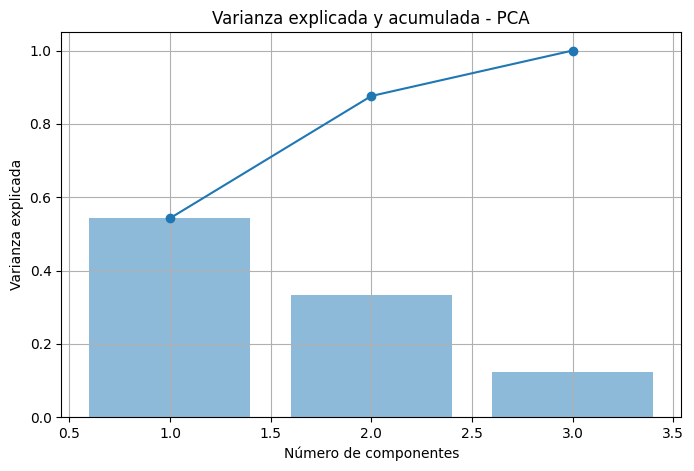

In [11]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_exp)+1), var_exp_acum, marker='o')
plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.5)
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Varianza explicada y acumulada - PCA")
plt.grid(True)
plt.show()

In [13]:
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=X.columns)

for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].sort_values(ascending=False))


PC1
cantidad_mb         0.707121
vlmen_fndo_ttal     0.707008
dias_inv_proceso    0.010933
Name: PC1, dtype: float64

PC2
dias_inv_proceso    0.999835
cantidad_mb         0.002547
vlmen_fndo_ttal    -0.018008
Name: PC2, dtype: float64

PC3
cantidad_mb         0.707088
dias_inv_proceso   -0.014534
vlmen_fndo_ttal    -0.706976
Name: PC3, dtype: float64


In [14]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"], index=X.index)
df_pca.head()

,PC1,PC2
0,-0.237233,0.185489
1,-0.502990,0.184590
2,-0.500582,0.184598
3,-0.226796,0.181010
4,-0.502990,0.184590


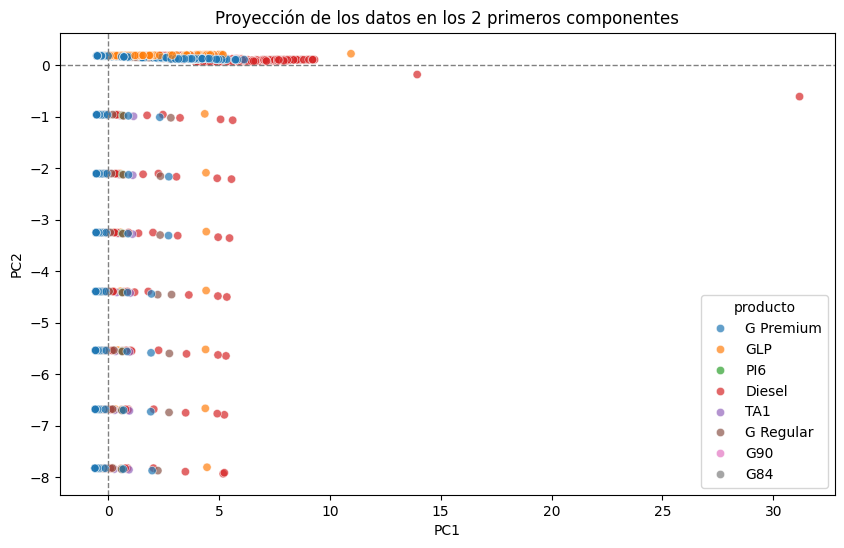

In [15]:
df_plot = df.loc[X.index].copy()
df_plot["PC1"] = df_pca["PC1"]
df_plot["PC2"] = df_pca["PC2"]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="producto", alpha=0.7)
plt.title("Proyección de los datos en los 2 primeros componentes")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.show()

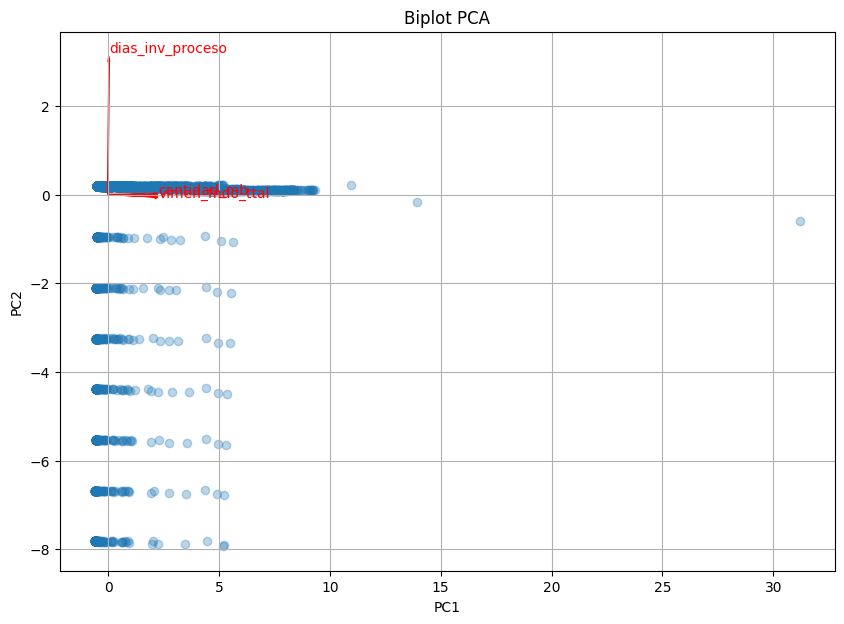

In [16]:
plt.figure(figsize=(10,7))
plt.scatter(df_pca["PC1"], df_pca["PC2"], alpha=0.3)

for i, var in enumerate(variables_pca):
    plt.arrow(
        0, 0,
        loadings.loc[var, "PC1"] * 3,
        loadings.loc[var, "PC2"] * 3,
        head_width=0.08,
        color='red'
    )
    plt.text(
        loadings.loc[var, "PC1"] * 3.2,
        loadings.loc[var, "PC2"] * 3.2,
        var,
        color='red'
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Biplot PCA")
plt.grid(True)
plt.show()

In [17]:
resultado = df.loc[X.index].copy()
resultado["PC1"] = df_pca["PC1"]
resultado["PC2"] = df_pca["PC2"]

resultado.to_excel("/content/resultado_pca.xlsx", index=False)
print("Archivo guardado: /content/resultado_pca.xlsx")

Archivo guardado: /content/resultado_pca.xlsx
